# Optimization

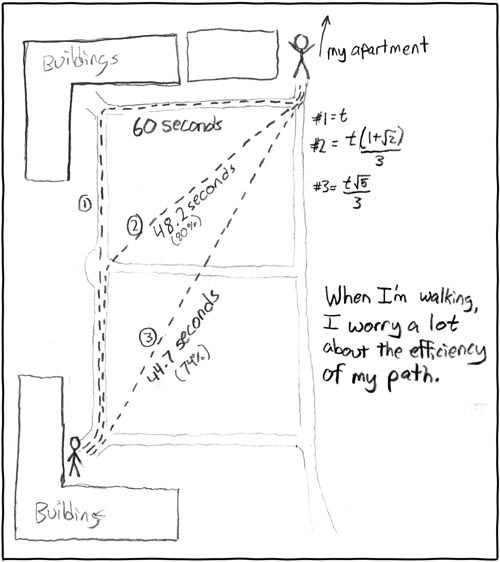

**Learning Objectives**: After completing this lesson, I hope you can:

* Define optimization and explain the difference between a local and a global minimum/maximum.


* REMEMBER how to model scattered data by fitting a polynomial function to it using Python's scipy.optimize.curve_fit library. (from last week!!)


* Apply brute-force and grid-search methods to find an optimal point and articulate their limitations

* Use a numerical solver like scipy.optimize.minimize to efficiently find the optimum of a model


* Analyze non-quadratic (cubic) problems and use the function's derivative to find significant points of interest

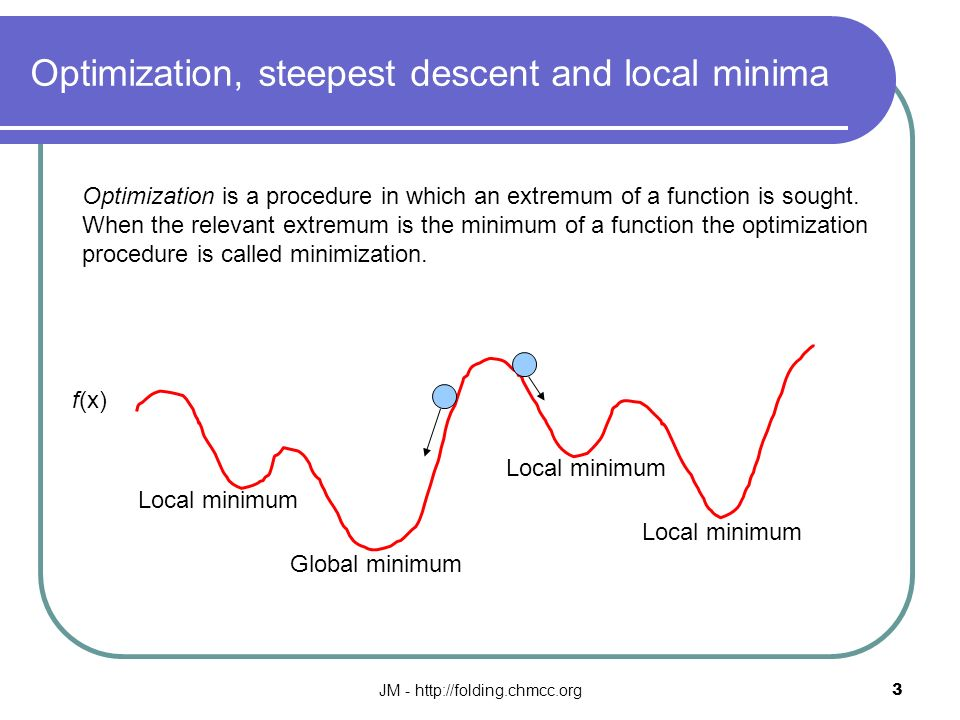

## examples of optimization in AE:

Fundamental Scheduling Procedures
https://www.cmu.edu/cee/projects/PMbook/10_Fundamental_Scheduling_Procedures.html

Lighting:
https://www.tandfonline.com/doi/full/10.1080/15502724.2018.1518717

Structural:
Steel beam sizing
a bit beyond this class: https://www.sciencedirect.com/science/article/pii/S0045794915001418

Mechanical:
Optimization of energy draw: https://www.ef.org/2019/08/20/energy-optimization-its-time-to-reimagine-energy-efficiency/




Let's look at data from the study "Height and Construction Costs of Residential High-Rise Buildings in Shanghai"

https://ascelibrary.org/doi/pdf/10.1061/%28ASCE%29CO.1943-7862.0000226


In [ ]:
import numpy as np

# the x -> height of the building and the y -> cost in Yen/m2

# approximation of data shown in the paper (given) # don't worry about this cell
x = np.linspace(0, 120, 100) # start, stop, number of samples
print("size of our dataset: ", len(x))

y = (79/4200)*x**2-(1039*x/420)+101  + np.random.randn(len(x)) * 5

In [ ]:
# plot the data

import matplotlib.pyplot as plt  # Import the Matplotlib library

# Plot x and y data as dots
fig, ax = plt.subplots()
ax.scatter(x, y)

# Set the x and y axis labels
ax.set_xlabel('building height (m)')
ax.set_ylabel('cost (Yen/m2)')

# Display the plot
plt.show()

# brute force optimization

What if we want to find the best value to choose for `x`?
(Not the y but the x)


In [ ]:
print('the min is ', min(y))

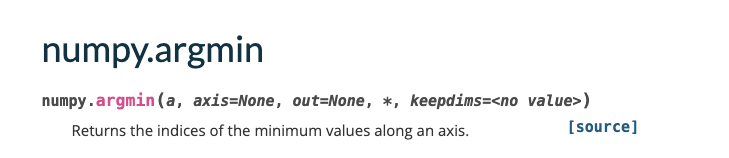

In [ ]:
# where is that minimum

y_min_index = np.argmin(y)


**Question:** Okay so what is min_y_index? What does it represent?

So how can we find the min value?

In [ ]:
min_x = x[y_min_index]

print('the minimum cost is for building height = ', x[np.argmin(y)], 'm')

But this minimum is more based on the exact data we have and not the "spirit" of the data.

By spirit of the data we mean model. So let's model it!

### **Your turn #1** ⏰ (10mins)

Try to model the following function and fit the curve fit to predict the y values for the given x using the given function and add the line to your plot from above. Submit the snippet below for your in-class assignment.

function to model: $y = a*(x-b)^2 + c*(x-d) + e$

In [ ]:
# your code here

---
## 📋 Today's In-Class Assignment

**Your turn #1 above is your in-class assignment for today. Submit it to Canvas before you leave.**

To submit:
1. Make sure your code in the cell above runs without errors (press Shift+Enter to run it)
2. Take a screenshot of your code and its output
3. Go to the module on Canvas that this lesson was part of and find today's in-class assignment, due at midnight
4. Upload your screenshot

*If you have multiple screenshots, combine them into a single PDF before uploading.*

**You only need to show that you tried; this is graded on effort, not perfection.**

---

Now that we have a reasonable model for the data, we can find its minimum.


## grid search


Of course we can calculate every value at a pre-determined resolution and use `np.min` again using a rather tedious method called grid search.

Where we literally draw a grid on our data and look to see what is happening at each point.

So below we have a 5 by 5 grid which means we would look at 25 points to see what is happening at each of them.

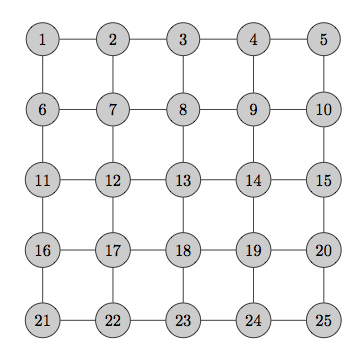

So in our case we would only have a 1d grid search problem.

Let's create our "grid" and then see what is the smallest y we can get with those search points.

In [ ]:
# our grid is
x_test = x
y_test = model_fn(x,a,b,c,d,e)

# get index with np.argmin()
min_index = np.argmin(y_test)
print(min_index)

# get min y
y_min = y_test[min_index]
print(y_min)

Then once you know your minimum y you can figure out at which x it occurred.

In [ ]:
# find x min
x_min = x_test[min_index]
print(x_min)

Okay so let's add that minimum to our plot!

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.plot(x, y_predict, "orange")
# ax.plot(x_min, model_fn(x_min, a,b,c,d,e), '^', markersize = 16) # or you can do it all in one line
ax.plot(x_min, y_min, '^', markersize=16, color='green')

ax.set_xlabel('building height (m)')
ax.set_ylabel('cost (Yen/m2)')

plt.show()

This approach has a few limitations:

* **Limited Precision:** Since we are not using an infinite number of grid points, the method does not guarantee finding the true minimum (or achieving the desired precision).
* **Range Dependency:** The actual minimum might fall outside the tested range. While this is trivial for the current quadratic example (since we can visually confirm it is within the range), this will not always be the case for more complex functions.


### Trying more grid points

OK, let's try to solve these problems by including more numbers. A lot more - 10 million values.

In [ ]:
x_test2 = np.linspace(0, 120, int(1e7)) # look at a bigger space, use 10 million values!

y_test2 = model_fn(x_test2, a, b, c, d, e)

min_index2 = np.argmin(y_test2)

y_min2 = y_test2[min_index2]

x_min2 = x_test2[min_index2]

print('minimum value is y ', y_min2)

print('minimum occurs at x ', x_min2)

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.plot(x, y_predict, "orange")
ax.plot(x_min, y_min, '^', markersize=16, color='green')
ax.plot(x_min2, y_min2, 'v', markersize=20, color='red')

ax.set_xlabel('building height (m)')
ax.set_ylabel('cost (Yen/m2)')

plt.show()

After increasing the number of grid points to 10million, we managed to slightly reduce the min value for our function. However, this approach still has limitations:

* **Computational Inefficiency:** Despite the simplicity and speed of evaluating the function itself, the process becomes slow due to the large number of grid points.
* **No Guarantee of the True Minimum:** Even with 10 million points, we are still not guaranteed to find the true minimum.


## 💡 **Curse of Dimensionality**
The problem becomes significantly worse when dealing with **high-dimensional data**, which is common in architectural engineering problems.

In other words, *high dimensional data is when there is a lot of "directions" to search in*, it can be very difficult to find the real minimum.

As the number of dimensions increases, the amount of data required to sufficiently cover the space grows exponentially. This makes it increasingly difficult to find the real minimum.

* For 2D, to try 100 values in each direction is $100^2 = 10^4$ total calculations.

* Now in 3D that's $100^3 = 10^6$

* And in 10 dimensions it's $100^{10} = 10^{20}$ values!

Even for a simple function like the one we have above, this is totally intractable.



### Dimensionality example in AE:

Imagine you are optimizing the layout of structural walls in a building to minimize material usage while meeting stability and load-bearing requirements.

- 2D (floor plan optimization), you might vary:
x-position and y-position of the walls → 2 dimensions

- 3D (considering wall height and floor thickness), you add another variable:
Height of the walls → 3 dimensions

- 10 variables (e.g., wall position, height, width, thickness, orientation, material type, load-bearing capacity, cost factors, thermal performance, and daylight exposure).